In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sales = pd.read_csv('../data/sales.csv')
sales = sales[sales["Price"] > 0].copy()

In [4]:
sales["InvoiceDate"] = pd.to_datetime(sales["InvoiceDate"])
monthly_sales = (
    sales
    .assign(
        Month=sales["InvoiceDate"].dt.to_period("M")
    )
    .groupby("Month")
    .agg(
        Revenue=("Revenue", "sum"),
        Orders=("Invoice", "nunique")
    )
    .reset_index()
)

monthly_sales["Month"] = (
    monthly_sales["Month"]
    .astype(str)
)

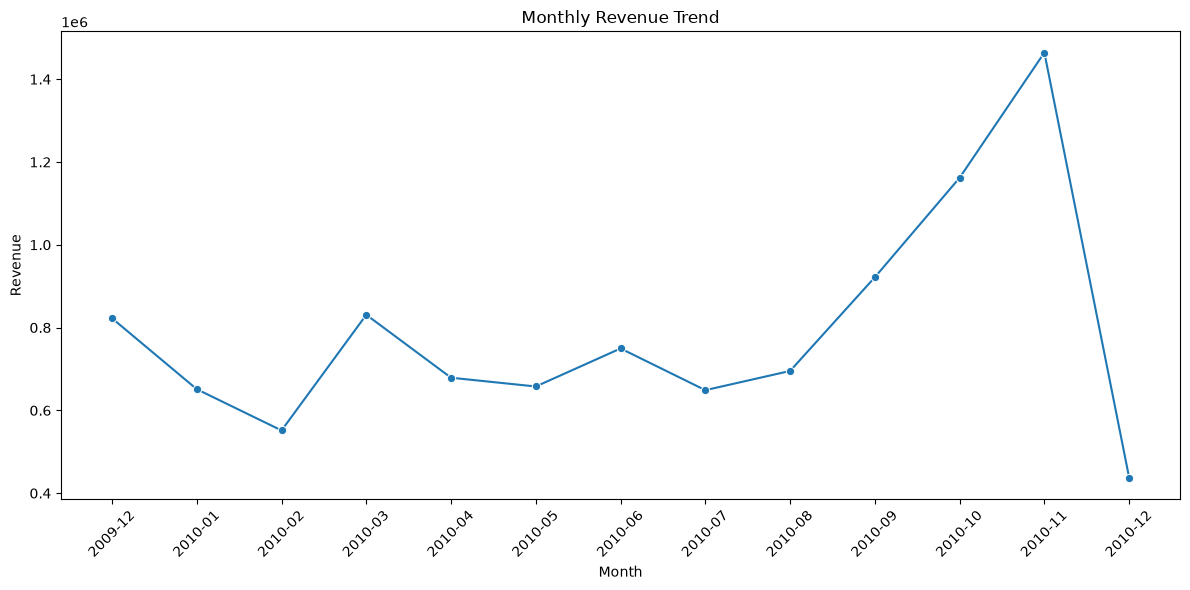

In [5]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_sales,
    x="Month",
    y="Revenue",
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(
    "../outputs/monthly_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [6]:
## fig 2: Top 10 products by revenue
special_codes = ["DOT", "M", "POST"]

product_sales = sales[
    ~sales["StockCode"].isin(special_codes)
].copy()
top_products_revenue = (
    product_sales.groupby(['StockCode','Description'])
    .agg(
        Revenue = ('Revenue','sum'),
        Units = ('Quantity', 'sum')
    )
    .sort_values('Revenue',ascending=False)
    .head(10)
    .reset_index()
)

print("Top 10 Products by Revenue:")
print(top_products_revenue)

Top 10 Products by Revenue:
  StockCode                          Description    Revenue  Units
0     22423             REGENCY CAKESTAND 3 TIER  169912.76  13685
1    85123A   WHITE HANGING HEART T-LIGHT HOLDER  158305.72  58386
2     84879        ASSORTED COLOUR BIRD ORNAMENT   72890.19  45228
3     22086      PAPER CHAIN KIT 50'S CHRISTMAS    58127.30  17205
4    85099B              JUMBO BAG RED RETROSPOT   54368.82  30327
5     47566                        PARTY BUNTING   49664.12  10079
6     84347  ROTATING SILVER ANGELS T-LIGHT HLDR   47954.49  23037
7    15056N            EDWARDIAN PARASOL NATURAL   36251.10   7416
8     21621           VINTAGE UNION JACK BUNTING   36023.71   4144
9    85099F                 JUMBO BAG STRAWBERRY   35887.14  19835


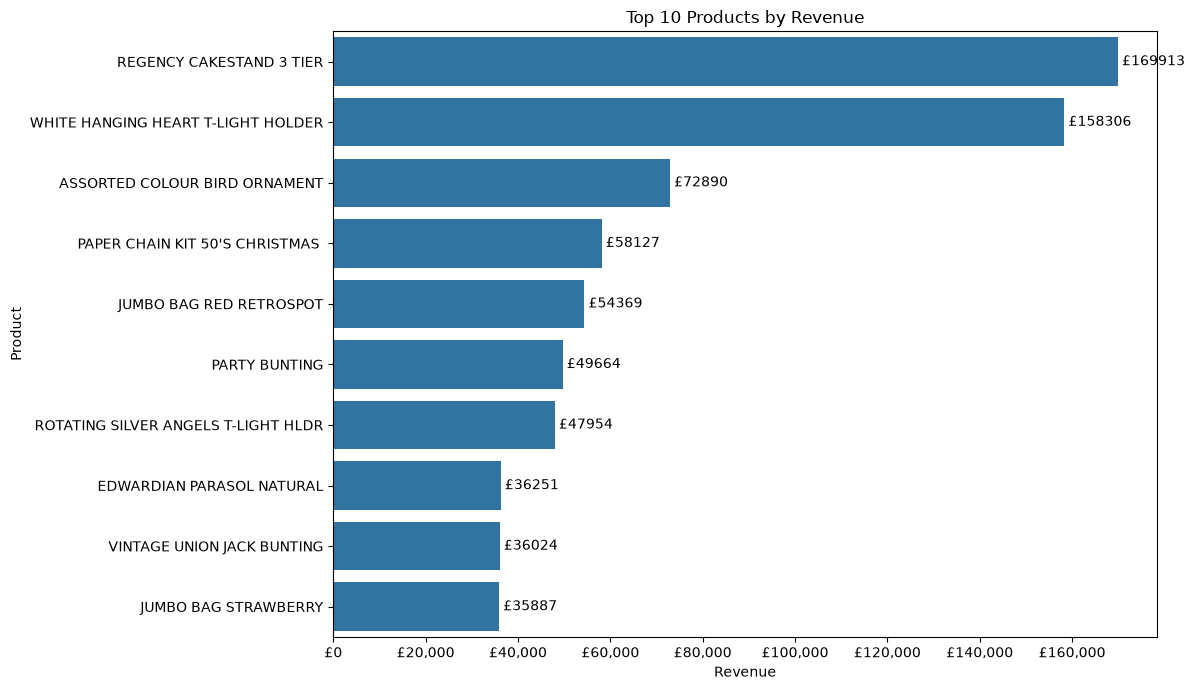

In [7]:
from matplotlib.ticker import FuncFormatter
plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_products_revenue,
    x="Revenue",
    y="Description"
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"£{x:,.0f}")
)

for container in plt.gca().containers:
    plt.bar_label(
        container,
        fmt="£%.0f",
        padding=3
    )

plt.tight_layout()

plt.savefig(
    "../outputs/top_10_products_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [9]:
## Top 10 products by units sold
top_products_units = (
    product_sales.groupby(['StockCode','Description'])
    .agg(
        Revenue = ('Revenue','sum'),
        Units = ('Quantity','sum')
    )
    .sort_values('Units',ascending=False)
    .head(10)
    .reset_index()
)

print("Top 10 products by units sold")
print(top_products_units)

Top 10 products by units sold
  StockCode                         Description    Revenue  Units
0    85123A  WHITE HANGING HEART T-LIGHT HOLDER  158305.72  58386
1     84077   WORLD WAR 2 GLIDERS ASSTD DESIGNS   11383.97  54947
2     17003                 BROCADE RING PURSE     8922.80  48374
3     21212    PACK OF 72 RETRO SPOT CAKE CASES   24054.43  46728
4     84879       ASSORTED COLOUR BIRD ORNAMENT   72890.19  45228
5     84991         60 TEATIME FAIRY CAKE CASES   18151.40  36348
6     21977  PACK OF 60 PINK PAISLEY CAKE CASES   16187.31  31805
7    85099B             JUMBO BAG RED RETROSPOT   54368.82  30327
8     22197                SMALL POPCORN HOLDER   27022.23  29773
9     21232      STRAWBERRY CERAMIC TRINKET BOX   34411.68  27059


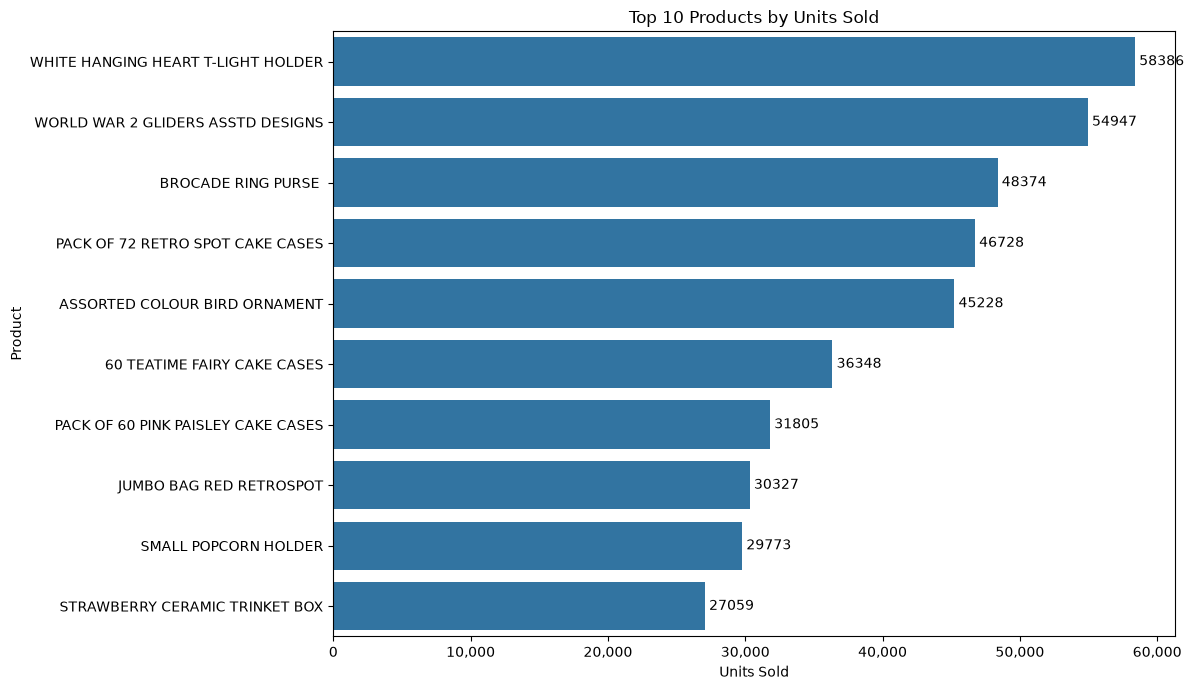

In [10]:
plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=top_products_units,
    x="Units",
    y="Description"
)

plt.title("Top 10 Products by Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Product")

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x:,.0f}")
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=3
    )

plt.tight_layout()

plt.savefig(
    "../outputs/top_10_products_units.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [11]:
## Revenue by Country
top_countries = (
    product_sales.groupby('Country')
    .agg(
        Revenue = ('Revenue','sum'),
        Orders = ('Invoice','nunique'),
        Units = ('Quantity','sum')
        
    )
    .sort_values('Revenue',ascending=False)
    .head(10)
    .reset_index()
)

print("Top 10 Countries by Revenue:")
print(top_countries)

Top 10 Countries by Revenue:
          Country      Revenue  Orders    Units
0  United Kingdom  8484099.703   19108  4698733
1            EIRE   364099.450     325   193024
2     Netherlands   266061.670     124   183463
3         Germany   183020.171     328   107636
4          France   132524.440     230   162513
5         Denmark    50348.850      25   229659
6          Sweden    49490.310      65    52500
7           Spain    43082.660      61    22742
8     Switzerland    41182.390      36    22205
9       Australia    30313.350      35    20184


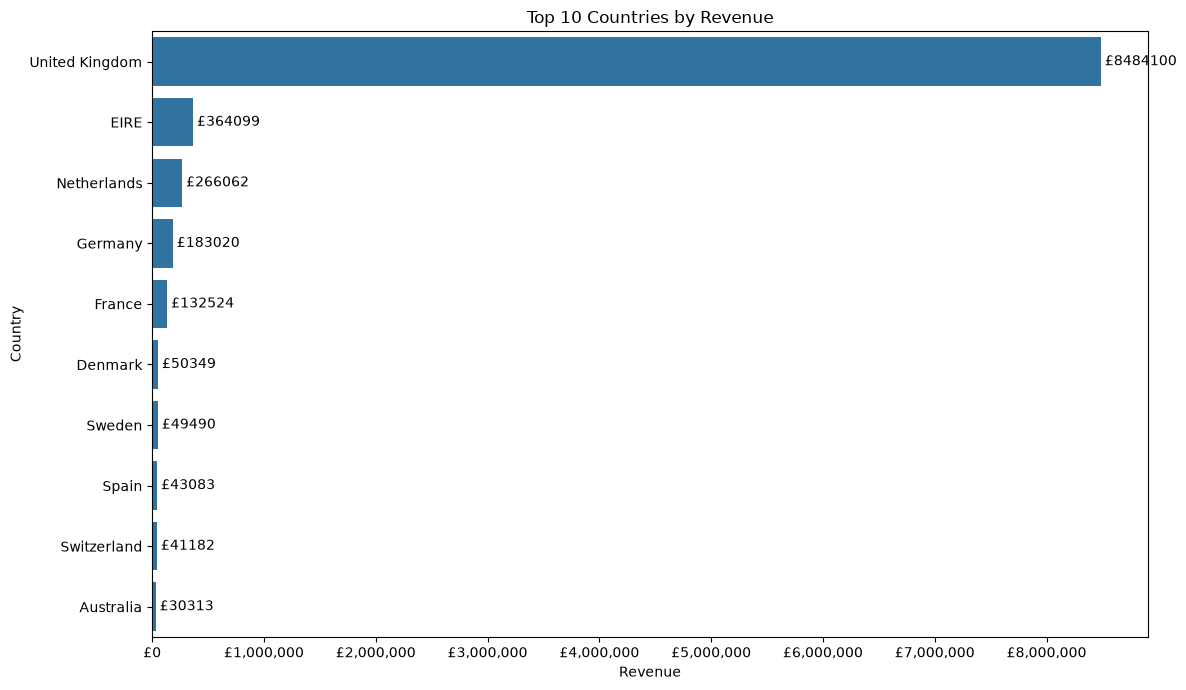

In [12]:
plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=top_countries,
    x="Revenue",
    y="Country"
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"£{x:,.0f}")
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="£%.0f",
        padding=3
    )

plt.tight_layout()

plt.savefig(
    "../outputs/top_10_countries_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [9]:
sales = sales.drop(
    columns=["Cohort_Month_x", "Cohort_Month_y"],
    errors="ignore"
)

In [10]:
import pandas as pd
sales = pd.read_csv('../data/cleaned_retail.csv')
sales["InvoiceDate"] = pd.to_datetime(sales["InvoiceDate"])
sales['Purchase_Month'] = sales['InvoiceDate'].dt.to_period("M")
customer_cohort = (
    sales.groupby("Customer ID")['Purchase_Month']
    .min()
    .reset_index()
    .rename(columns={"Purchase_Month": "Cohort_Month"})
)


In [11]:
sales = sales.merge(
    customer_cohort,
    on="Customer ID",
    how="left"
)

In [12]:
sales["Cohort_Index"] = (
    (sales["Purchase_Month"].dt.year - sales["Cohort_Month"].dt.year) * 12
    + (sales["Purchase_Month"].dt.month - sales["Cohort_Month"].dt.month)
)

In [8]:
print(sales.columns.tolist())

['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'Revenue', 'Purchase_Month', 'Cohort_Month_x', 'Cohort_Month_y']


In [17]:
print(
    sales[
        ["Customer ID", "Purchase_Month", "Cohort_Month", "Cohort_Index"]
    ].head(10)
)

   Customer ID Purchase_Month Cohort_Month  Cohort_Index
0      13085.0        2009-12      2009-12             0
1      13085.0        2009-12      2009-12             0
2      13085.0        2009-12      2009-12             0
3      13085.0        2009-12      2009-12             0
4      13085.0        2009-12      2009-12             0
5      13085.0        2009-12      2009-12             0
6      13085.0        2009-12      2009-12             0
7      13085.0        2009-12      2009-12             0
8      13085.0        2009-12      2009-12             0
9      13085.0        2009-12      2009-12             0


In [18]:
cohort_data = (
    sales
    .groupby(["Cohort_Month", "Cohort_Index"])["Customer ID"]
    .nunique()
    .reset_index()
)

cohort_data.head(10)

,Cohort_Month,Cohort_Index,Customer ID
0,2009-12,0,955
1,2009-12,1,337
2,2009-12,2,319
3,2009-12,3,406
4,2009-12,4,363
5,2009-12,5,343
6,2009-12,6,360
7,2009-12,7,327
8,2009-12,8,321
9,2009-12,9,346


In [19]:
cohort_matrix = cohort_data.pivot(
    index="Cohort_Month",
    columns="Cohort_Index",
    values="Customer ID"
)
print(cohort_matrix)

Cohort_Index     0      1      2      3      4      5      6      7      8   \
Cohort_Month                                                                  
2009-12       955.0  337.0  319.0  406.0  363.0  343.0  360.0  327.0  321.0   
2010-01       383.0   79.0  119.0  117.0  101.0  115.0   99.0   88.0  107.0   
2010-02       376.0   89.0   84.0  109.0   92.0   75.0   72.0  107.0   95.0   
2010-03       443.0   84.0  102.0  107.0  103.0   90.0  109.0  134.0  122.0   
2010-04       294.0   57.0   57.0   48.0   54.0   66.0   81.0   77.0   20.0   
2010-05       254.0   40.0   43.0   44.0   45.0   65.0   54.0   20.0    NaN   
2010-06       270.0   47.0   51.0   55.0   62.0   77.0   18.0    NaN    NaN   
2010-07       186.0   29.0   34.0   55.0   54.0   19.0    NaN    NaN    NaN   
2010-08       162.0   33.0   48.0   52.0   19.0    NaN    NaN    NaN    NaN   
2010-09       243.0   55.0   57.0   24.0    NaN    NaN    NaN    NaN    NaN   
2010-10       377.0   97.0   35.0    NaN    NaN    N

In [20]:
retention_matrix = cohort_matrix.divide(
    cohort_matrix.iloc[:, 0],
    axis=0
) * 100

In [21]:
print(retention_matrix.round(2))

Cohort_Index     0      1      2      3      4      5      6      7      8   \
Cohort_Month                                                                  
2009-12       100.0  35.29  33.40  42.51  38.01  35.92  37.70  34.24  33.61   
2010-01       100.0  20.63  31.07  30.55  26.37  30.03  25.85  22.98  27.94   
2010-02       100.0  23.67  22.34  28.99  24.47  19.95  19.15  28.46  25.27   
2010-03       100.0  18.96  23.02  24.15  23.25  20.32  24.60  30.25  27.54   
2010-04       100.0  19.39  19.39  16.33  18.37  22.45  27.55  26.19   6.80   
2010-05       100.0  15.75  16.93  17.32  17.72  25.59  21.26   7.87    NaN   
2010-06       100.0  17.41  18.89  20.37  22.96  28.52   6.67    NaN    NaN   
2010-07       100.0  15.59  18.28  29.57  29.03  10.22    NaN    NaN    NaN   
2010-08       100.0  20.37  29.63  32.10  11.73    NaN    NaN    NaN    NaN   
2010-09       100.0  22.63  23.46   9.88    NaN    NaN    NaN    NaN    NaN   
2010-10       100.0  25.73   9.28    NaN    NaN    N

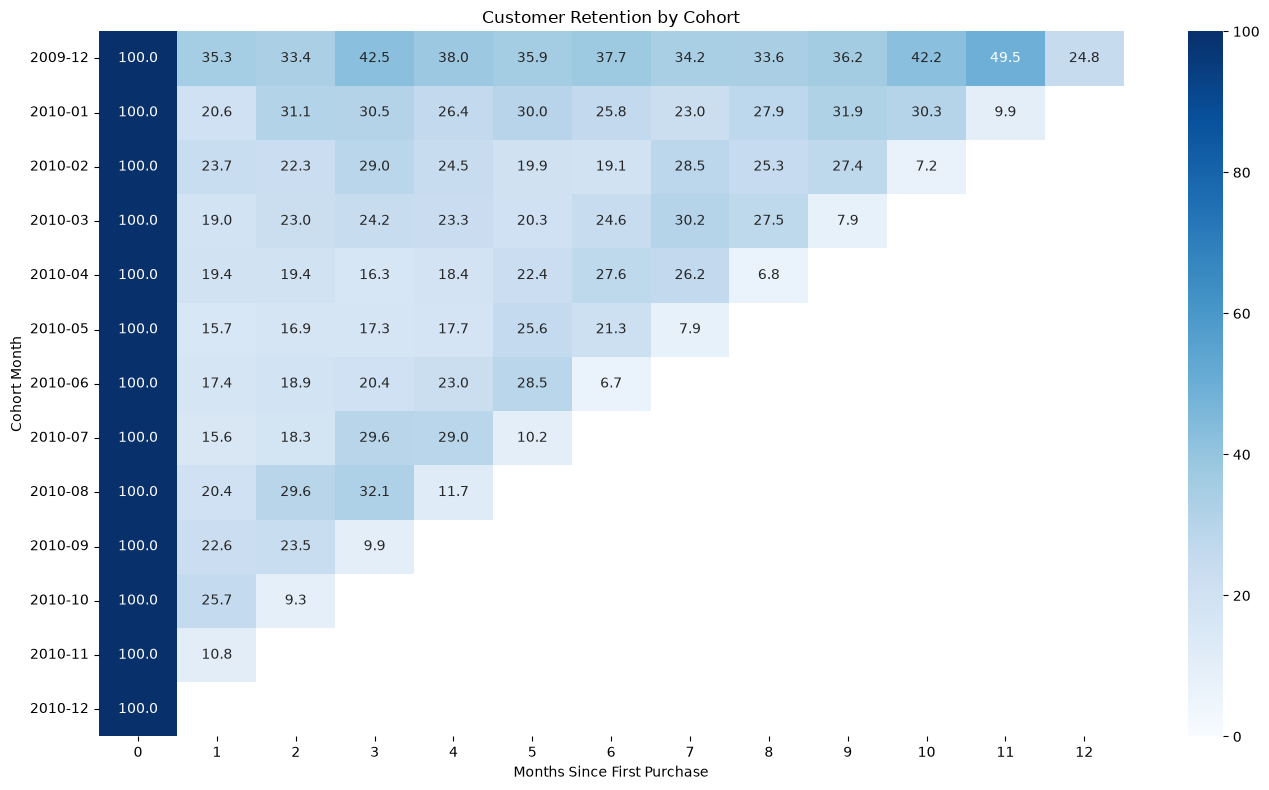

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))

sns.heatmap(
    retention_matrix,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    vmin=0,
    vmax=100
)

plt.title("Customer Retention by Cohort")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")

plt.tight_layout()

plt.savefig(
    "../outputs/cohort_retention_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
average_retention = retention_matrix.mean(axis=0)

print("Average Retention by Month:")
print(average_retention.round(2))

Average Retention by Month:
Cohort_Index
0     100.00
1      20.52
2      22.34
3      25.18
4      23.55
5      24.12
6      23.25
7      25.00
8      24.23
9      25.84
10     26.56
11     29.73
12     24.82
dtype: float64


In [26]:
print(
    f"Average Month 1 Retention: "
    f"{average_retention.iloc[1]:.2f}%"
)

Average Month 1 Retention: 20.52%


In [27]:
if len(average_retention) > 3:
    print(
        f"Average Month 3 Retention: "
        f"{average_retention.iloc[3]:.2f}%"
    )

Average Month 3 Retention: 25.18%
